<a href="https://colab.research.google.com/github/saradindu-chaudhuri/SC/blob/master/Vascular_Risk_Survival_and_Explainable_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install required packages
!pip install ucimlrepo lifelines shap matplotlib seaborn
!pip install scikit-survival

# 2. Fetch the Heart Failure Clinical Records dataset directly from UCI
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset (UCI ID: 519)
heart_failure = fetch_ucirepo(id=519)

# Extract features (X) and target (y)
X = heart_failure.data.features
y = heart_failure.data.targets

# Combine into a single clean DataFrame
df = pd.concat([X, y], axis=1)

print("Dataset Loaded Successfully!")
print(f"Shape: {df.shape} (Patients: {df.shape[0]}, Features: {df.shape[1]})")
df.head()

Dataset Loaded Successfully!
Shape: (299, 13) (Patients: 299, Features: 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


/tmp/ipykernel_6969/3294309564.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='death_event', y='ejection_fraction', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_6969/3294309564.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Censored / Survived (0)', 'Event / Deceased (1)'])
/tmp/ipykernel_6969/3294309564.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='death_event', y='serum_creatinine', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_6969/3294309564.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

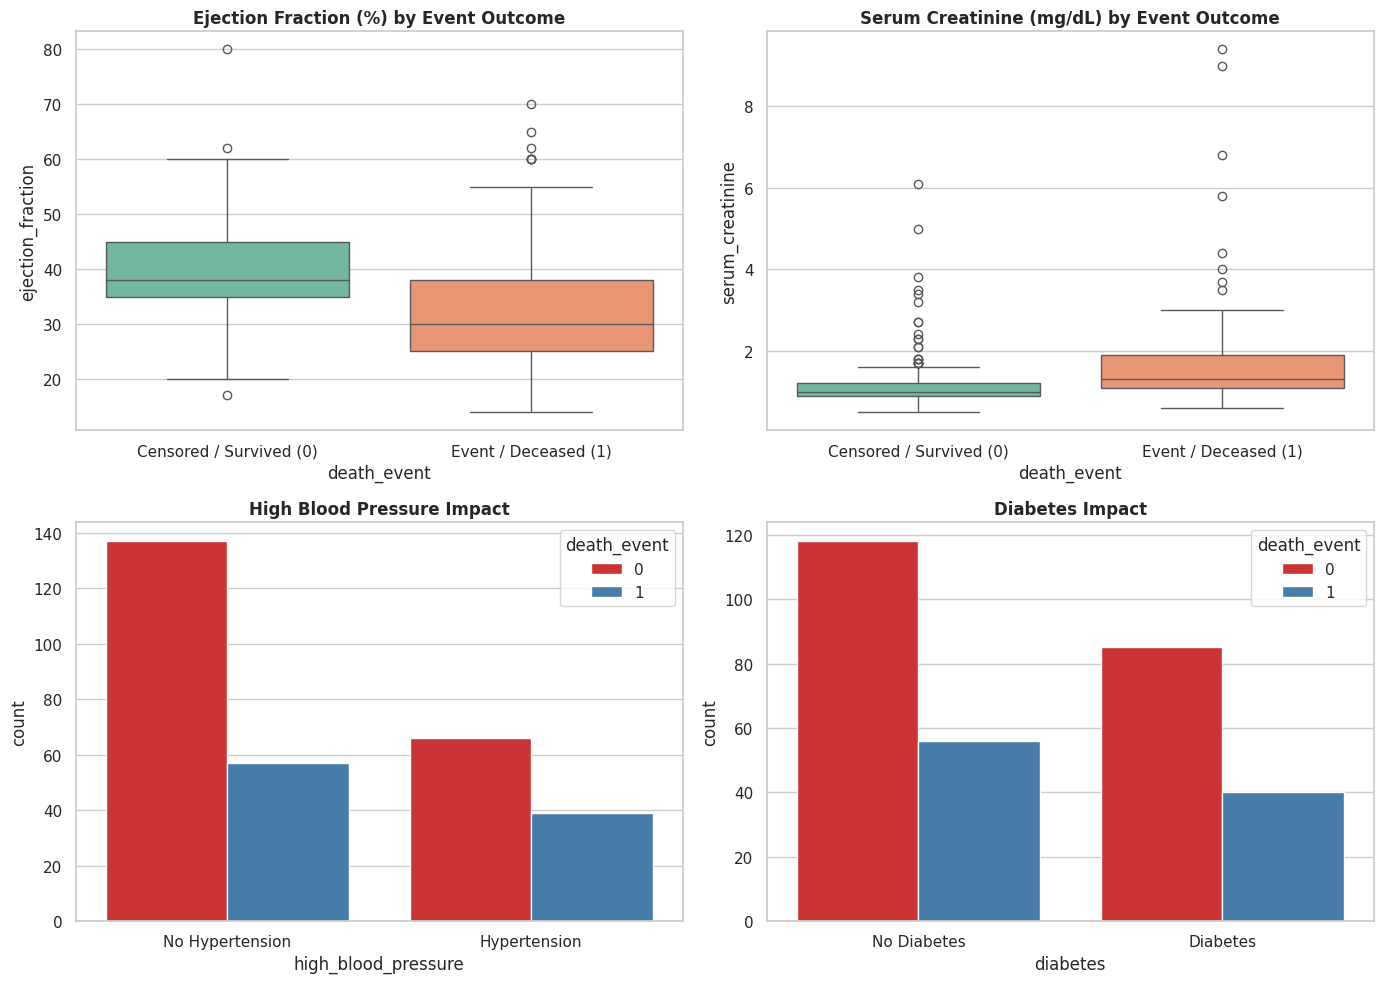

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Ejection Fraction by Event Status
sns.boxplot(data=df, x='death_event', y='ejection_fraction', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Ejection Fraction (%) by Event Outcome', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['Censored / Survived (0)', 'Event / Deceased (1)'])

# 2. Serum Creatinine Levels by Event Status
sns.boxplot(data=df, x='death_event', y='serum_creatinine', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Serum Creatinine (mg/dL) by Event Outcome', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['Censored / Survived (0)', 'Event / Deceased (1)'])

# 3. High Blood Pressure Breakdown
sns.countplot(data=df, x='high_blood_pressure', hue='death_event', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('High Blood Pressure Impact', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(['No Hypertension', 'Hypertension'])

# 4. Diabetes Breakdown
sns.countplot(data=df, x='diabetes', hue='death_event', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Diabetes Impact', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

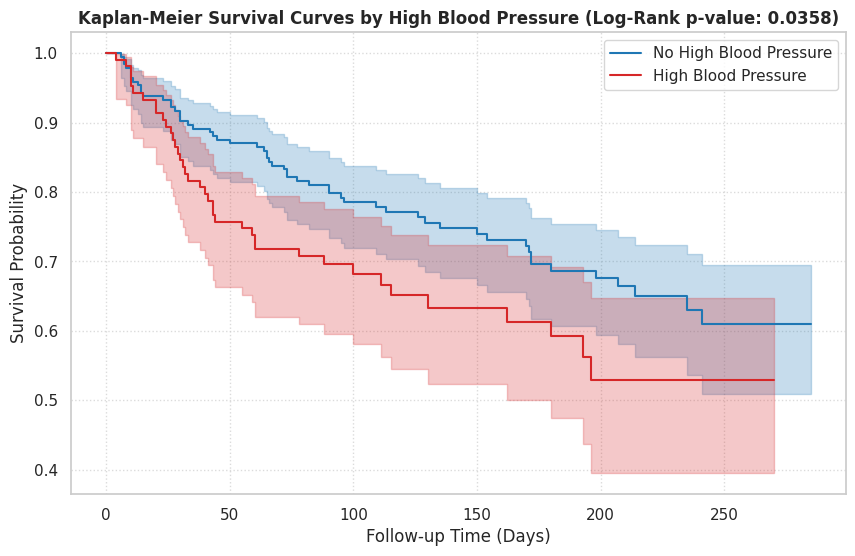

Log-Rank Test p-value: 0.0358


In [3]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf_no_hbp = KaplanMeierFitter()
kmf_hbp = KaplanMeierFitter()

# Split data by High Blood Pressure status
mask_hbp = (df['high_blood_pressure'] == 1)

plt.figure(figsize=(10, 6))

# 1. Fit No High Blood Pressure
kmf_no_hbp.fit(
    durations=df.loc[~mask_hbp, 'time'],
    event_observed=df.loc[~mask_hbp, 'death_event'],
    label='No High Blood Pressure'
)
kmf_no_hbp.plot_survival_function(ci_show=True, color='#1f77b4')

# 2. Fit High Blood Pressure
kmf_hbp.fit(
    durations=df.loc[mask_hbp, 'time'],
    event_observed=df.loc[mask_hbp, 'death_event'],
    label='High Blood Pressure'
)
kmf_hbp.plot_survival_function(ci_show=True, color='#d62728')

# 3. Log-Rank Test
results = logrank_test(
    df.loc[~mask_hbp, 'time'], df.loc[mask_hbp, 'time'],
    df.loc[~mask_hbp, 'death_event'], df.loc[mask_hbp, 'death_event']
)

plt.title(f'Kaplan-Meier Survival Curves by High Blood Pressure (Log-Rank p-value: {results.p_value:.4f})', fontweight='bold')
plt.xlabel('Follow-up Time (Days)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

print(f"Log-Rank Test p-value: {results.p_value:.4f}")

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'death_event'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.23
         time fit was run = 2026-07-31 02:16:24 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.05      1.05      0.01            0.03            0.06                1.03                1.07
anaemia                   0.46      1.58      0.22            0.04            0.89                1.04                2.42
creatinine_phosphokinase  0.00      1.00      0.00            0.00            0.00                1.00                1.00
diabetes                  0.14      1.15      0.22           -0.30            0.58                0.74                1.78
ejection_fraction        -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
high_blood_pressure       0.48      1.61      0.22            0.05            0.90                1.05                2.46
platelets                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          0.32      1.38      0.07            0.18            0.46                1.20                1.58
serum_sodium             -0.04      0.96      0.02           -0.09            0.00                0.91                1.00
sex                      -0.24      0.79      0.25           -0.73            0.26                0.48                1.29
smoking                   0.13      1.14      0.25           -0.36            0.62                0.70                1.86

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  4.98 <0.005     20.56
anaemia                     0.00  2.12   0.03      4.89
creatinine_phosphokinase    0.00  2.23   0.03      5.26
diabetes                    0.00  0.63   0.53      0.91
ejection_fraction           0.00 -4.67 <0.005     18.35
high_blood_pressure         0.00  2.20   0.03      5.17
platelets                   0.00 -0.41   0.68      0.56
serum_creatinine            0.00  4.58 <0.005     17.68
serum_sodium                0.00 -1.90   0.06      4.12
sex                         0.00 -0.94   0.35      1.53
smoking                     0.00  0.51   0.61      0.72
---
Concordance = 0.74
Partial AIC = 958.46
log-likelihood ratio test = 81.95 on 11 df
-log2(p) of ll-ratio test = 40.56

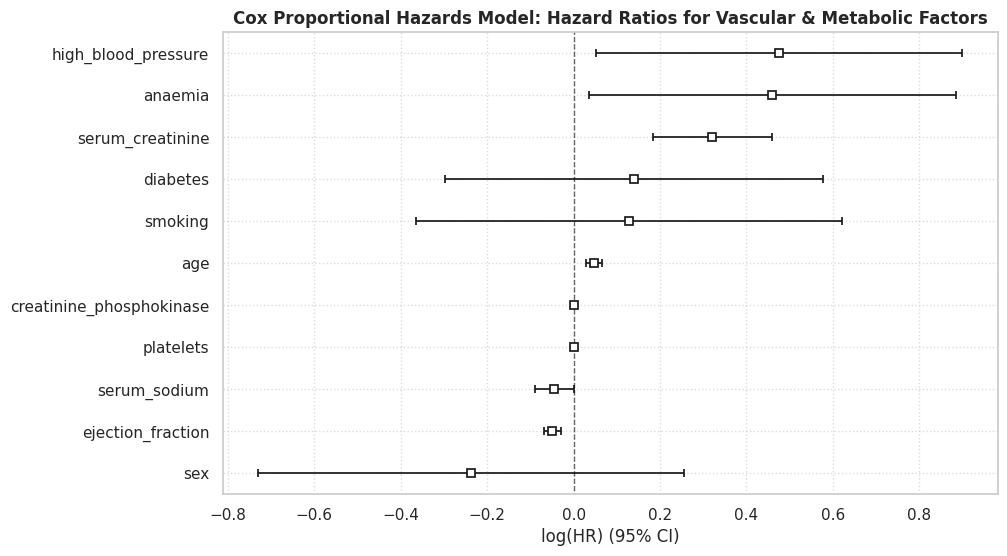

In [4]:
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Fit Cox PH model on all clinical and vascular features
cph = CoxPHFitter()
cph.fit(df, duration_col='time', event_col='death_event')

# Print statistical summary
cph.print_summary()

# Plot Hazard Ratios
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Cox Proportional Hazards Model: Hazard Ratios for Vascular & Metabolic Factors', fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Best RSF Parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 100}
Tuned 5-Fold RSF C-Index: 0.742


PermutationExplainer explainer: 300it [11:27,  2.31s/it]
/tmp/ipykernel_6969/896330900.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_vasc, feature_names=features)


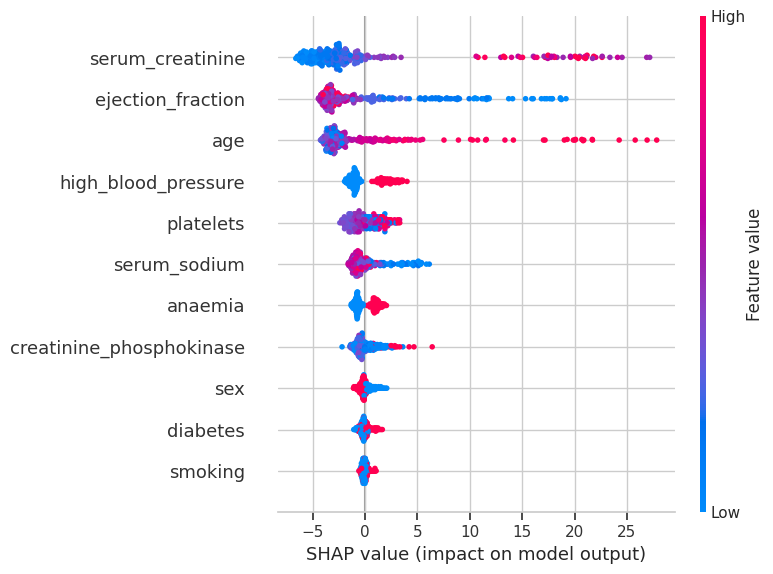

In [7]:
import numpy as np
import shap
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import GridSearchCV

# 1. Prepare Features & Structured Target
features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
            'ejection_fraction', 'high_blood_pressure', 'platelets',
            'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

X_vasc = df[features]
y_vasc = np.array(
    [(bool(event), time) for event, time in zip(df['death_event'], df['time'])],
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 2. Tune Random Survival Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 8],
    'min_samples_leaf': [5, 10]
}

rsf_base = RandomSurvivalForest(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rsf_base, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_vasc, y_vasc)

print(f"Best RSF Parameters: {grid_search.best_params_}")
print(f"Tuned 5-Fold RSF C-Index: {grid_search.best_score_:.3f}")

# 3. Compute SHAP values on Best Estimator
best_rsf = grid_search.best_estimator_

# Use shap.Explainer for feature attributions, as TreeExplainer does not support sksurv models.
# The 'predict' method of RandomSurvivalForest returns risk scores.
explainer = shap.Explainer(best_rsf.predict, X_vasc)
shap_values = explainer(X_vasc)

# Plot SHAP Summary
shap.summary_plot(shap_values, X_vasc, feature_names=features)

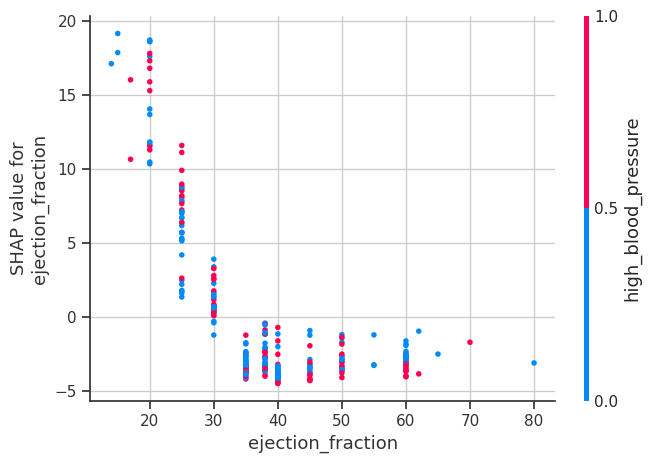

In [9]:
# SHAP Dependence Plot: Interaction between Ejection Fraction and High Blood Pressure
shap.dependence_plot(
    "ejection_fraction",
    shap_values.values, # Use .values to get the numerical SHAP values
    X_vasc,
    interaction_index="high_blood_pressure"
)